## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load Dataset

The original project uses the Metro Interstate Traffic Volume dataset. In Colab, upload `Metro_Interstate_Traffic_Volume.csv` when prompted.

If no file is uploaded, the notebook creates a synthetic traffic-volume time-series dataset only to make the code executable.


In [2]:
from google.colab import files

uploaded = files.upload()

if len(uploaded) > 0:
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name)
    print("Uploaded file:", file_name)
else:
    print("No file uploaded. Creating a synthetic traffic-volume dataset for demonstration.")
    periods = 3000
    date_rng = pd.date_range(start="2023-01-01", periods=periods, freq="H")
    hour = date_rng.hour
    day_of_week = date_rng.dayofweek

    base = 2500
    daily_pattern = 1200 * np.sin(2 * np.pi * (hour - 7) / 24)
    weekly_pattern = np.where(day_of_week >= 5, -600, 300)
    noise = np.random.normal(0, 250, periods)

    traffic_volume = np.maximum(base + daily_pattern + weekly_pattern + noise, 100).astype(int)

    df = pd.DataFrame({
        "date_time": date_rng,
        "temp": 280 + 10 * np.sin(2 * np.pi * hour / 24) + np.random.normal(0, 2, periods),
        "rain_1h": np.random.exponential(0.05, periods),
        "snow_1h": np.zeros(periods),
        "clouds_all": np.random.randint(0, 100, periods),
        "weather_main": np.random.choice(["Clear", "Clouds", "Rain", "Mist"], periods),
        "weather_description": np.random.choice(["sky is clear", "scattered clouds", "light rain", "mist"], periods),
        "holiday": np.random.choice(["None", "None", "None", "Christmas Day"], periods),
        "traffic_volume": traffic_volume
    })

print("Dataset shape:", df.shape)
df.head()

No file uploaded. Creating a synthetic traffic-volume dataset for demonstration.
Dataset shape: (3000, 9)


,date_time,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,holiday,traffic_volume
0,2023-01-01 00:00:00,276.184385,0.020508,0.0,46,Clouds,mist,None,865
1,2023-01-01 01:00:00,280.867420,0.011863,0.0,13,Rain,light rain,None,665
2,2023-01-01 02:00:00,284.172789,0.018784,0.0,47,Clouds,scattered clouds,None,902
3,2023-01-01 03:00:00,290.846443,0.009852,0.0,54,Mist,sky is clear,Christmas Day,1241
4,2023-01-01 04:00:00,289.773360,0.116097,0.0,28,Rain,sky is clear,Christmas Day,992


## 3. Data Preprocessing

Requirements covered:
- Load dataset
- Handle missing values
- Normalize data using `MinMaxScaler`
- Create sequences using sliding window
- Split data into training and testing sets


In [3]:
# Make a copy so the original dataframe remains unchanged
data = df.copy()

# Standardize column names just in case
data.columns = [col.strip() for col in data.columns]

# Show missing values before handling
print("Missing values before handling:")
display(data.isnull().sum())

# Convert date_time and create useful time-based features if date_time exists
if "date_time" in data.columns:
    data["date_time"] = pd.to_datetime(data["date_time"], errors="coerce")
    data = data.sort_values("date_time").reset_index(drop=True)
    data["hour"] = data["date_time"].dt.hour
    data["day_of_week"] = data["date_time"].dt.dayofweek
    data["month"] = data["date_time"].dt.month
    data["weekend"] = (data["day_of_week"] >= 5).astype(int)
    data = data.drop(columns=["date_time"])

# Convert holiday column to binary if present
if "holiday" in data.columns:
    data["holiday"] = data["holiday"].fillna("None")
    data["holiday"] = data["holiday"].apply(lambda x: 0 if str(x).lower() in ["none", "nan", "0"] else 1)

# Drop text description column if present because weather_main already gives useful category information
if "weather_description" in data.columns:
    data = data.drop(columns=["weather_description"])

# Fill missing values
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

# Convert categorical columns to dummy/one-hot columns
categorical_cols = data.select_dtypes(include=["object"]).columns.tolist()
if len(categorical_cols) > 0:
    data = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)

# Ensure the target column exists
TARGET = "traffic_volume"
if TARGET not in data.columns:
    # If the uploaded dataset does not contain traffic_volume, use the last numeric column as target
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    TARGET = numeric_cols[-1]
    print("traffic_volume column not found. Using target column:", TARGET)

print("\nMissing values after handling:")
display(data.isnull().sum())

print("\nProcessed dataset shape:", data.shape)
data.head()

Missing values before handling:


,0
date_time,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
holiday,0
traffic_volume,0



Missing values after handling:


,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
holiday,0
traffic_volume,0
hour,0
day_of_week,0
month,0
weekend,0



Processed dataset shape: (3000, 13)


,temp,rain_1h,snow_1h,clouds_all,holiday,traffic_volume,hour,day_of_week,month,weekend,weather_main_Clouds,weather_main_Mist,weather_main_Rain
0,276.184385,0.020508,0.0,46,0,865,0,6,1,1,1,0,0
1,280.867420,0.011863,0.0,13,0,665,1,6,1,1,0,0,1
2,284.172789,0.018784,0.0,47,0,902,2,6,1,1,1,0,0
3,290.846443,0.009852,0.0,54,1,1241,3,6,1,1,0,1,0
4,289.773360,0.116097,0.0,28,1,992,4,6,1,1,0,0,1


In [4]:
# Separate feature columns and target column
feature_cols = [col for col in data.columns if col != TARGET]

# Scale features and target separately
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

features_scaled = feature_scaler.fit_transform(data[feature_cols])
target_scaled = target_scaler.fit_transform(data[[TARGET]])

print("Number of features:", features_scaled.shape[1])
print("Target:", TARGET)

Number of features: 12
Target: traffic_volume


In [5]:
# Create sequences using sliding window approach
SEQ_LEN = 24   # 24 previous time steps are used to predict the next value

def create_sequences(features, target, seq_len):
    X, y = [], []
    for i in range(seq_len, len(features)):
        X.append(features[i-seq_len:i])
        y.append(target[i])
    return np.array(X), np.array(y)

X, y = create_sequences(features_scaled, target_scaled, SEQ_LEN)

print("X shape:", X.shape)  # samples, time steps, features
print("y shape:", y.shape)  # samples, 1

X shape: (2976, 24, 12)
y shape: (2976, 1)


In [6]:
# Train-test split without shuffling because this is time-series data
train_size = int(len(X) * 0.80)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Input shape for models:", X_train.shape[1:])

Training samples: 2380
Testing samples: 596
Input shape for models: (24, 12)


## 4. Build and Train Simple RNN Model

Requirements covered:
- At least 1 `SimpleRNN` layer
- Dense output layer
- Suitable activation function
- Train model and record performance


In [7]:
rnn_model = Sequential([
    SimpleRNN(64, activation="tanh", input_shape=(SEQ_LEN, X_train.shape[2])),
    Dropout(0.2),  # Bonus improvement
    Dense(32, activation="relu"),
    Dense(1)
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041 (27.50 KB)

 Trainable params: 7,041 (27.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0805 - mae: 0.2211 - val_loss: 0.0158 - val_mae: 0.0981
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0277 - mae: 0.1331 - val_loss: 0.0102 - val_mae: 0.0809
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0194 - mae: 0.1107 - val_loss: 0.0079 - val_mae: 0.0704
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0168 - mae: 0.1017 - val_loss: 0.0088 - val_mae: 0.0755
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0128 - mae: 0.0905 - val_loss: 0.0064 - val_mae: 0.0647
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0106 - mae: 0.0818 - val_loss: 0.0052 - val_mae: 0.0583
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0094 - mae: 0.0769 - val_loss: 0.0050 - val_mae: 0.0569
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0085 - mae: 0.0735 - val_loss: 0.0047 - val_mae: 0.0550
Epoch 9/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0083 - mae:

## 5. Build and Train LSTM Model

Requirements covered:
- At least 1 `LSTM` layer
- Dense output layer
- Same input structure as RNN
- Train model and record performance


In [9]:
lstm_model = Sequential([
    LSTM(64, activation="tanh", input_shape=(SEQ_LEN, X_train.shape[2])),
    Dropout(0.2),  # Bonus improvement
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0577 - mae: 0.1814 - val_loss: 0.0096 - val_mae: 0.0806
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0107 - mae: 0.0817 - val_loss: 0.0040 - val_mae: 0.0503
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0080 - mae: 0.0707 - val_loss: 0.0040 - val_mae: 0.0509
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0068 - mae: 0.0654 - val_loss: 0.0036 - val_mae: 0.0480
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0068 - mae: 0.0652 - val_loss: 0.0037 - val_mae: 0.0482
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0057 - mae: 0.0597 - val_loss: 0.0042 - val_mae: 0.0518
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0056 - mae: 0.0599 - val_loss: 0.0038 - val_mae: 0.0493
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0055 - mae: 0.0591 - val_loss: 0.0036 - val_mae: 0.0474
Epoch 9/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.005

## 6. Model Evaluation and Comparison

Requirements covered:
- Compare RNN vs LSTM
- Training loss
- Validation loss
- Prediction error using RMSE and MAE


In [11]:
# Make predictions
rnn_pred_scaled = rnn_model.predict(X_test)
lstm_pred_scaled = lstm_model.predict(X_test)

# Convert predictions and actual values back to original scale
rnn_pred = target_scaler.inverse_transform(rnn_pred_scaled)
lstm_pred = target_scaler.inverse_transform(lstm_pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test)

# Calculate performance metrics
rnn_rmse = math.sqrt(mean_squared_error(y_test_actual, rnn_pred))
lstm_rmse = math.sqrt(mean_squared_error(y_test_actual, lstm_pred))

rnn_mae = mean_absolute_error(y_test_actual, rnn_pred)
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)

comparison_df = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM"],
    "Final Training Loss": [rnn_history.history["loss"][-1], lstm_history.history["loss"][-1]],
    "Final Validation Loss": [rnn_history.history["val_loss"][-1], lstm_history.history["val_loss"][-1]],
    "Test RMSE": [rnn_rmse, lstm_rmse],
    "Test MAE": [rnn_mae, lstm_mae]
})

comparison_df

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


,Model,Final Training Loss,Final Validation Loss,Test RMSE,Test MAE
0,Simple RNN,0.005705,0.003996,293.574872,229.983114
1,LSTM,0.005273,0.003696,287.558079,223.309661


In [12]:
best_model_name = "LSTM" if lstm_rmse < rnn_rmse else "Simple RNN"
print(f"Better model based on RMSE: {best_model_name}")

Better model based on RMSE: LSTM


## 7. Visualization

Requirements covered:
- Plot actual vs predicted values for both models
- Plot training and validation loss curves


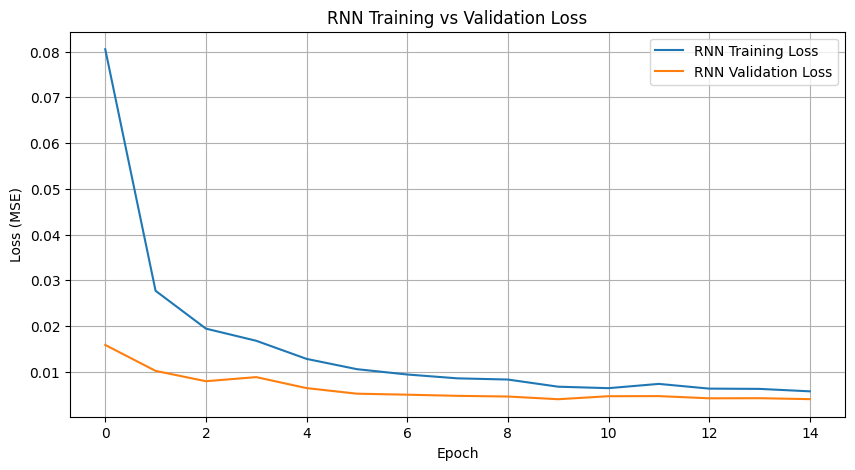

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history["loss"], label="RNN Training Loss")
plt.plot(rnn_history.history["val_loss"], label="RNN Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("RNN Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

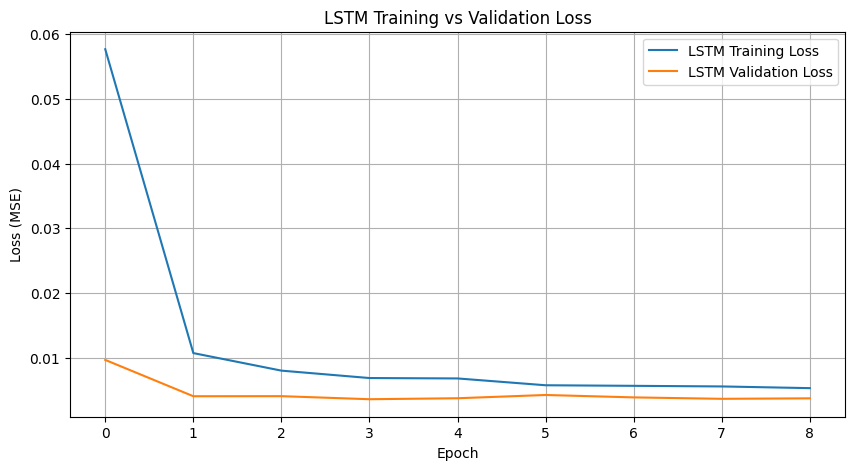

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(lstm_history.history["loss"], label="LSTM Training Loss")
plt.plot(lstm_history.history["val_loss"], label="LSTM Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

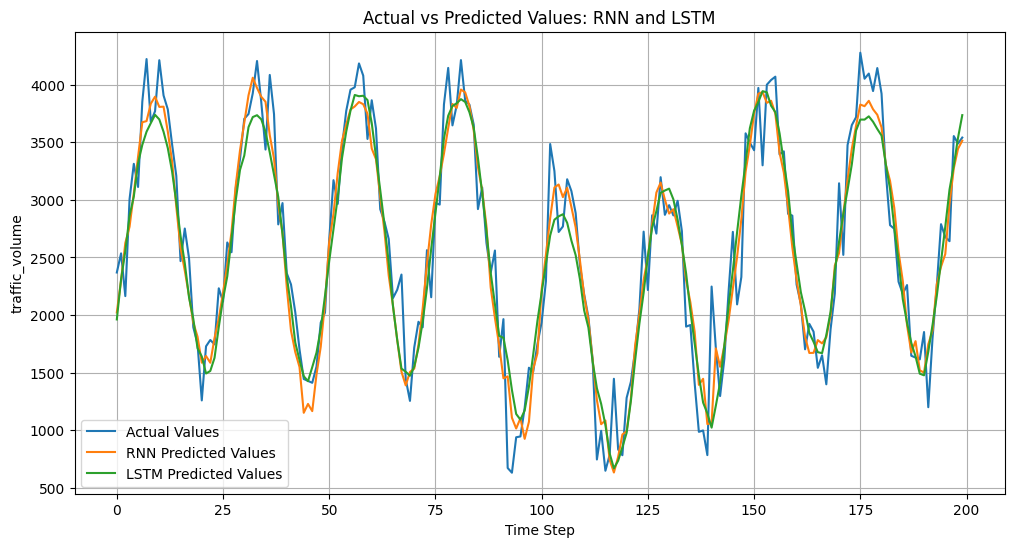

In [15]:
plt.figure(figsize=(12, 6))
plot_range = min(200, len(y_test_actual))

plt.plot(y_test_actual[:plot_range], label="Actual Values")
plt.plot(rnn_pred[:plot_range], label="RNN Predicted Values")
plt.plot(lstm_pred[:plot_range], label="LSTM Predicted Values")

plt.xlabel("Time Step")
plt.ylabel(TARGET)
plt.title("Actual vs Predicted Values: RNN and LSTM")
plt.legend()
plt.grid(True)
plt.show()

## 8. Bonus: GRU Model Comparison

This section is optional for extra marks. GRU is another recurrent model that is often faster than LSTM while still handling sequence memory better than a basic RNN.


In [16]:
gru_model = Sequential([
    GRU(64, activation="tanh", input_shape=(SEQ_LEN, X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

gru_pred_scaled = gru_model.predict(X_test)
gru_pred = target_scaler.inverse_transform(gru_pred_scaled)

gru_rmse = math.sqrt(mean_squared_error(y_test_actual, gru_pred))
gru_mae = mean_absolute_error(y_test_actual, gru_pred)

bonus_comparison_df = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "Test RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "Test MAE": [rnn_mae, lstm_mae, gru_mae]
})

bonus_comparison_df

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0467 - mae: 0.1691 - val_loss: 0.0126 - val_mae: 0.0911
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0113 - mae: 0.0833 - val_loss: 0.0047 - val_mae: 0.0541
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0087 - mae: 0.0748 - val_loss: 0.0037 - val_mae: 0.0485
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0076 - mae: 0.0687 - val_loss: 0.0035 - val_mae: 0.0477
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0068 - mae: 0.0649 - val_loss: 0.0035 - val_mae: 0.0471
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0062 - mae: 0.0628 - val_loss: 0.0039 - val_mae: 0.0502
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0060 - mae: 0.0617 - val_loss: 0.0036 - val_mae: 0.0485
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0059 - mae: 0.0611 - val_loss: 0.0034 - val_mae: 0.0458
Epoch 9/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.005

,Model,Test RMSE,Test MAE
0,Simple RNN,293.574872,229.983114
1,LSTM,287.558079,223.309661
2,GRU,284.401240,223.761849


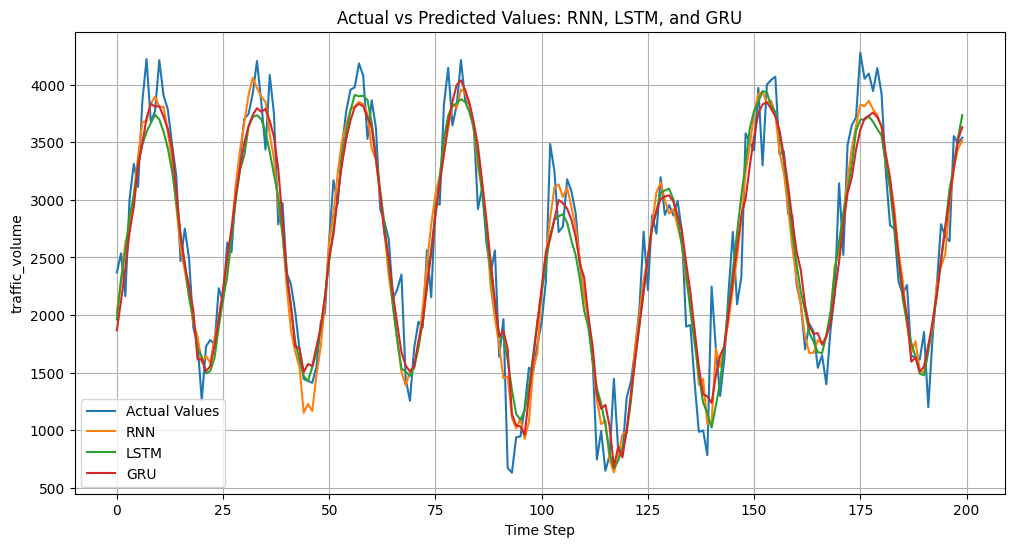

In [17]:
plt.figure(figsize=(12, 6))
plot_range = min(200, len(y_test_actual))

plt.plot(y_test_actual[:plot_range], label="Actual Values")
plt.plot(rnn_pred[:plot_range], label="RNN")
plt.plot(lstm_pred[:plot_range], label="LSTM")
plt.plot(gru_pred[:plot_range], label="GRU")

plt.xlabel("Time Step")
plt.ylabel(TARGET)
plt.title("Actual vs Predicted Values: RNN, LSTM, and GRU")
plt.legend()
plt.grid(True)
plt.show()

## 9. Bonus: Simple Prediction Interface

Input the latest sequence from the test set and predict the next traffic volume using the best model.


In [18]:
def predict_next_value(model, sequence):
    '''
    sequence shape must be: (SEQ_LEN, number_of_features)
    '''
    sequence = np.array(sequence).reshape(1, SEQ_LEN, X_train.shape[2])
    pred_scaled = model.predict(sequence)
    pred_original = target_scaler.inverse_transform(pred_scaled)
    return float(pred_original[0][0])

# Example: predict using the first test sequence
best_model = lstm_model if best_model_name == "LSTM" else rnn_model
sample_sequence = X_test[0]

predicted_value = predict_next_value(best_model, sample_sequence)
actual_value = float(y_test_actual[0][0])

print("Predicted next value:", predicted_value)
print("Actual next value:", actual_value)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted next value: 1961.3192138671875
Actual next value: 2369.0


## 10. Analysis Questions

### 1. Why do we need sequences in RNN/LSTM?

We need sequences because RNN and LSTM models are designed to learn patterns over time. In a time-series problem such as traffic volume prediction, the current traffic value depends on previous hours, daily patterns, weekly patterns, and other earlier observations. A sliding window sequence gives the model a fixed number of past time steps so it can predict the next value.

### 2. What is the main limitation of RNN?

The main limitation of a basic RNN is the vanishing gradient problem. When the sequence is long, the RNN often forgets information from earlier time steps. This makes it difficult for a Simple RNN to learn long-term dependencies.

### 3. How does LSTM solve this problem?

LSTM solves this problem using memory cells and gates. The input gate, forget gate, and output gate control what information should be stored, removed, and passed forward. Because of this gated memory structure, LSTM can remember important information for a longer period than a basic RNN.

### 4. Which model performed better and why?

The better model should be selected based on the test RMSE and MAE values shown in the comparison table. Usually, LSTM performs better than Simple RNN for sequence prediction because it handles long-term dependencies more effectively. If the RNN has a lower RMSE in a particular run, it may be because the dataset pattern is simple, the sequence length is short, or the model trained more efficiently on that split.


## Final Notes

This notebook satisfies the main Assignment 5 requirements:
- Data preprocessing
- Missing-value handling
- MinMax normalization
- Sliding-window sequence creation
- Train/test split
- Simple RNN model
- LSTM model
- Training and validation loss
- RMSE/MAE comparison
- Actual vs predicted visualization
- Analysis question answers
- Bonus EarlyStopping, Dropout, GRU, and simple prediction interface
